# 10 — Decision Tree Export for Deployment

**Goal:** Export the final decision tree's structure and automatically generate the
equivalent C code by walking sklearn's own tree internals directly — no manual
transcription. The generated C is verified against the trained Python model on every
row of the real labeled dataset before being trusted for deployment.

This replaces manual translation (reading `export_text()` output and hand-typing if/else
statements) with a deterministic generator: the C code is produced from the exact same
`tree_.feature` / `tree_.threshold` / `tree_.children_left` / `tree_.children_right`
arrays sklearn uses internally, so what gets deployed is guaranteed to match what was
evaluated in notebooks 07–09.

In [1]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt

MODELS_DIR = Path("../results/models")
FIGURES_DIR = Path("../results/figures")
PREPROCESSED_DIR = Path("../data/preprocessed")
TOOLS_DIR = Path("../tools")
TOOLS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = ["temperature_C", "humidity_pct", "soil_moisture_pct", "moisture_trend", "light_lux", "hour_of_day"]

with open(MODELS_DIR / "decision_tree.pkl", "rb") as f:
    dt_model = pickle.load(f)

print("Classes:", list(dt_model.classes_))
print("Tree depth:", dt_model.get_depth())
print("Number of leaves:", dt_model.get_n_leaves())

Classes: ['Not_Urgent', 'Soon', 'Urgent']
Tree depth: 5
Number of leaves: 16


## Full text export of the tree structure

Human-readable reference — every split condition and leaf value, in order. Useful for a quick sanity read, even though the C generation below doesn't parse this text (it reads the tree's internal arrays directly, which is more reliable).

In [2]:
tree_text = export_text(dt_model, feature_names=FEATURE_COLS, decimals=4)
print(tree_text)

|--- soil_moisture_pct <= 46.6250
|   |--- soil_moisture_pct <= 45.9400
|   |   |--- humidity_pct <= 50.1400
|   |   |   |--- humidity_pct <= 50.0600
|   |   |   |   |--- class: Urgent
|   |   |   |--- humidity_pct >  50.0600
|   |   |   |   |--- class: Soon
|   |   |--- humidity_pct >  50.1400
|   |   |   |--- class: Urgent
|   |--- soil_moisture_pct >  45.9400
|   |   |--- light_lux <= 190.7500
|   |   |   |--- class: Soon
|   |   |--- light_lux >  190.7500
|   |   |   |--- class: Urgent
|--- soil_moisture_pct >  46.6250
|   |--- soil_moisture_pct <= 68.1900
|   |   |--- soil_moisture_pct <= 48.9700
|   |   |   |--- light_lux <= 3906.4501
|   |   |   |   |--- class: Soon
|   |   |   |--- light_lux >  3906.4501
|   |   |   |   |--- class: Urgent
|   |   |--- soil_moisture_pct >  48.9700
|   |   |   |--- soil_moisture_pct <= 66.4250
|   |   |   |   |--- class: Soon
|   |   |   |--- soil_moisture_pct >  66.4250
|   |   |   |   |--- humidity_pct <= 54.5350
|   |   |   |   |   |--- class:

In [3]:
with open(TOOLS_DIR / "decision_tree_sklearn_export.txt", "w") as f:
    f.write(tree_text)
print("Saved decision_tree_sklearn_export.txt")

Saved decision_tree_sklearn_export.txt


## Visual reference

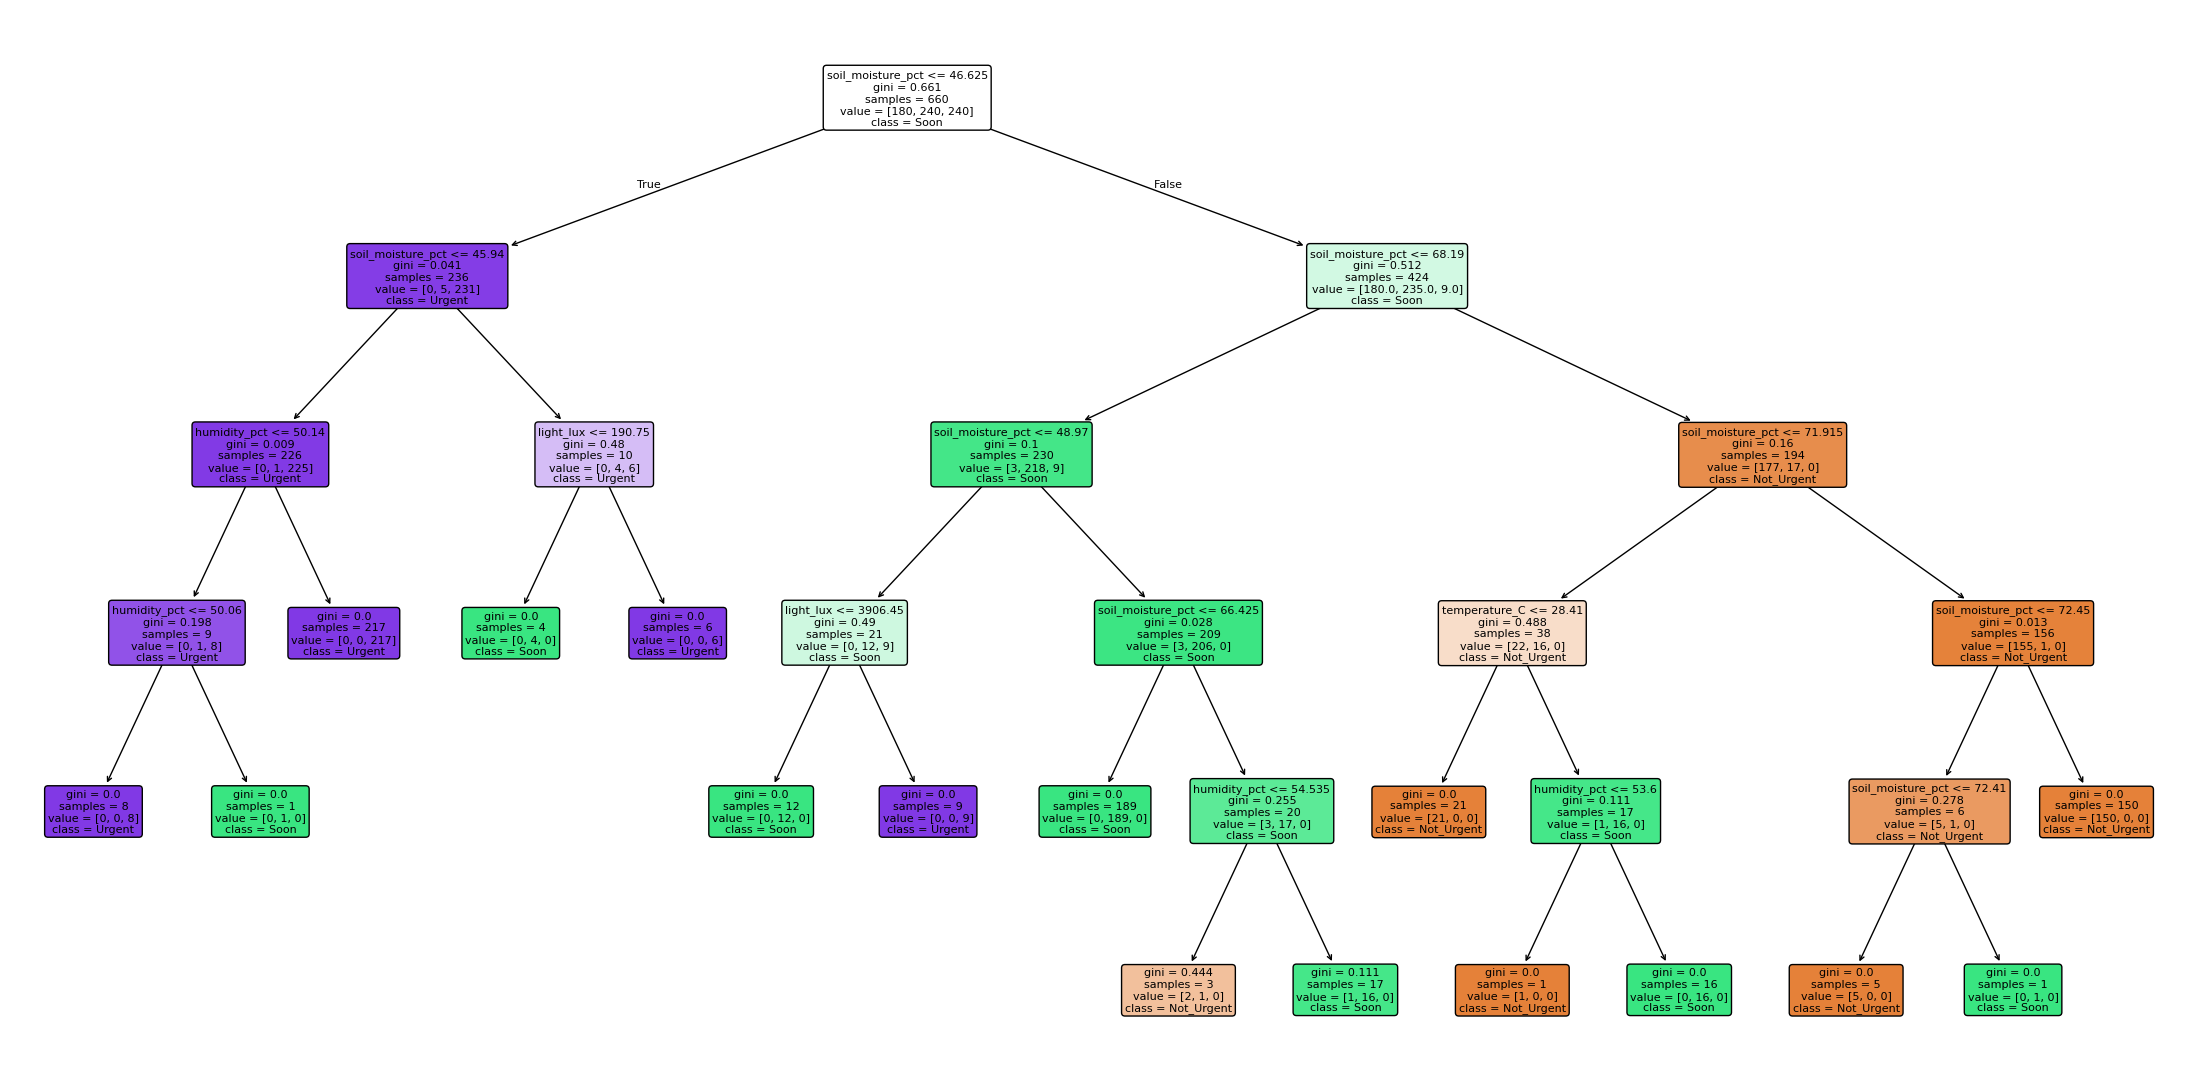

In [4]:
fig, ax = plt.subplots(figsize=(22, 11))
plot_tree(
    dt_model,
    feature_names=FEATURE_COLS,
    class_names=dt_model.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_decision_tree_for_export.png", dpi=150, bbox_inches="tight")
plt.show()

## Automatic C code generation

Walks `dt_model.tree_` directly (the same structure `.predict()` uses internally) and
emits the equivalent nested `if`/`else` C function plus a matching `UrgencyClass` enum.
No manual reading-and-retyping step, and therefore no manual-transcription risk between
this notebook and the firmware.

In [5]:
def sanitize_class_name(name):
    """Turn a class label into a valid C enum identifier."""
    return "URGENCY_" + name.upper().replace(" ", "_").replace("-", "_")


def generate_c_function(clf, feature_names, function_name="predict_urgency"):
    tree = clf.tree_
    class_names = list(clf.classes_)
    enum_names = [sanitize_class_name(c) for c in class_names]

    lines = []
    lines.append("// ============================================================")
    lines.append("// AUTO-GENERATED from trained sklearn DecisionTreeClassifier.")
    lines.append("// Do not hand-edit -- regenerate from the .pkl model instead,")
    lines.append("// so the deployed C code always matches the evaluated model.")
    lines.append("// ============================================================")
    lines.append("")
    lines.append("typedef enum {")
    for i, name in enumerate(enum_names):
        comma = "," if i < len(enum_names) - 1 else ""
        lines.append(f"    {name} = {i}{comma}")
    lines.append("} UrgencyClass;")
    lines.append("")

    params = ", ".join(f"float {f}" for f in feature_names)
    lines.append(f"UrgencyClass {function_name}({params}) {{")

    def recurse(node_id, depth):
        indent = "    " * (depth + 1)
        left = tree.children_left[node_id]
        right = tree.children_right[node_id]

        if left == right:  # leaf node
            class_index = int(np.argmax(tree.value[node_id][0]))
            lines.append(f"{indent}return {enum_names[class_index]};")
            return

        feature_index = tree.feature[node_id]
        feature_name = feature_names[feature_index]
        threshold = tree.threshold[node_id]

        lines.append(f"{indent}if ({feature_name} <= {threshold:.4f}f) {{")
        recurse(left, depth + 1)
        lines.append(f"{indent}}} else {{")
        recurse(right, depth + 1)
        lines.append(f"{indent}}}")

    recurse(0, 0)
    lines.append("}")
    lines.append("")
    return "\n".join(lines), class_names


c_code, class_names = generate_c_function(dt_model, FEATURE_COLS)
print(c_code)

// ============================================================
// AUTO-GENERATED from trained sklearn DecisionTreeClassifier.
// Do not hand-edit -- regenerate from the .pkl model instead,
// so the deployed C code always matches the evaluated model.
// ============================================================

typedef enum {
    URGENCY_NOT_URGENT = 0,
    URGENCY_SOON = 1,
    URGENCY_URGENT = 2
} UrgencyClass;

UrgencyClass predict_urgency(float temperature_C, float humidity_pct, float soil_moisture_pct, float moisture_trend, float light_lux, float hour_of_day) {
    if (soil_moisture_pct <= 46.6250f) {
        if (soil_moisture_pct <= 45.9400f) {
            if (humidity_pct <= 50.1400f) {
                if (humidity_pct <= 50.0600f) {
                    return URGENCY_URGENT;
                } else {
                    return URGENCY_SOON;
                }
            } else {
                return URGENCY_URGENT;
            }
        } else {
            if (light_lux <

In [6]:
with open(TOOLS_DIR / "decision_tree_auto_generated.c", "w") as f:
    f.write(c_code)
print("Saved decision_tree_auto_generated.c")

Saved decision_tree_auto_generated.c


## Verification: does the generated C logic match the trained Python model?

Re-implements the exact same tree-walk in pure Python (mirroring what the generated C
does step-for-step) and checks it agrees with `dt_model.predict()` on every row of the
real labeled dataset. **This is the check that matters before trusting the C port on
hardware** — 0 mismatches means the translation is faithful; any mismatch means the
generator (or, if hand-edited afterward, the edit) introduced a bug that must be fixed
before flashing.

In [7]:
def verify_c_logic_matches_python(clf, feature_names, X_sample):
    tree = clf.tree_
    class_names = list(clf.classes_)

    def walk(node_id, row):
        left = tree.children_left[node_id]
        right = tree.children_right[node_id]
        if left == right:
            class_index = int(np.argmax(tree.value[node_id][0]))
            return class_names[class_index]
        feature_index = tree.feature[node_id]
        threshold = tree.threshold[node_id]
        if row[feature_names[feature_index]] <= threshold:
            return walk(left, row)
        else:
            return walk(right, row)

    sklearn_preds = clf.predict(X_sample[feature_names])
    walked_preds = [walk(0, row) for _, row in X_sample.iterrows()]

    mismatches = sum(1 for a, b in zip(sklearn_preds, walked_preds) if a != b)
    return mismatches, len(sklearn_preds)


labeled_df = pd.read_csv(PREPROCESSED_DIR / "labeled_dataset.csv")
mismatches, total = verify_c_logic_matches_python(dt_model, FEATURE_COLS, labeled_df)

status = "PASS" if mismatches == 0 else "FAIL -- investigate before deploying"
print(f"Verification: {mismatches} mismatches out of {total} rows ({status})")

assert mismatches == 0, 'Generated C logic does not match the trained model -- do not deploy until fixed.'

Verification: 0 mismatches out of 660 rows (PASS)


## Hardware-side verification (do this once, on-device, before trusting it fully)

The check above proves the generator's logic is faithful *in Python*. Before fully
trusting the deployed system, also spot-check a handful of real feature rows through
the **actual compiled C function on the STM32** (or a desktop C test harness compiling
`decision_tree_auto_generated.c` directly) and confirm the outputs match the
`python_prediction` column below. This catches issues the Python-only check can't —
compiler quirks, float precision differences between Python and embedded C, or a copy
error if the `.c` file was manually edited after generation.

In [8]:
sample_rows = labeled_df.sample(n=min(8, len(labeled_df)), random_state=1)
X_sample = sample_rows[FEATURE_COLS]
predictions = dt_model.predict(X_sample)

verification_table = X_sample.copy()
verification_table["python_prediction"] = predictions
verification_table["c_prediction_on_device"] = ""  # fill in after testing on STM32

verification_table.to_csv(TOOLS_DIR / "c_port_verification_rows.csv", index=False)
print("Saved c_port_verification_rows.csv — fill in 'c_prediction_on_device' after testing on hardware")
verification_table

Saved c_port_verification_rows.csv — fill in 'c_prediction_on_device' after testing on hardware


,temperature_C,humidity_pct,soil_moisture_pct,moisture_trend,light_lux,hour_of_day,python_prediction,c_prediction_on_device
547,29.25,68.50,74.72,-2.85,8195.1,23,Not_Urgent,
353,29.13,67.33,80.09,-2.07,7574.5,6,Not_Urgent,
499,29.37,62.15,59.92,-2.98,8311.7,18,Soon,
173,25.68,53.05,58.14,-2.58,153.9,3,Soon,
241,27.25,53.28,57.27,-2.86,184.7,4,Soon,
341,26.82,47.67,28.61,-2.49,229.8,13,Urgent,
647,31.29,65.16,37.56,-3.73,11254.5,8,Urgent,
218,26.64,52.43,78.53,-2.48,152.7,5,Not_Urgent,


## Notes on feature usage

Not every one of the six features necessarily appears in the final tree — a shallow
tree only splits on whichever features it found most useful for separating classes in
the training data. Worth reporting explicitly in your write-up: check which of the six
features actually appear in the printed tree above, and note any that don't (e.g., if
`hour_of_day` or `moisture_trend` are absent, that's a real finding about this dataset,
not a bug — mention it rather than letting a reader assume all six were equally load-bearing.)